## Data

In [109]:
import pandas as pd

data = pd.read_csv("performance.csv")
data = data.drop("amp", axis=1).drop("info", axis=1)
data = data.rename(columns={
    "Model": "model",
    "latency(s)": "latency",
    "memory(m)": "memory",
    "cpu time(ms)": "cpu_time",
    "gpu time(ms)": "gpu_time"
})
data = data.dropna(subset=["model"]).fillna(0)

method_names = ["Original", "SOTA-Revs", "ReverSyn", "Checkpoint"]
model_names = ["ResNet32", "ResNet110", "ResNet164", "ResNet101-1k", "GPT", "Swin", "BERT", "ViT", "DeiT", "UNet", "BART", "YOSO"]

def rename_models(data):
    old = ["resnet32", "resnet110", "resnet164", "resnet101-1k", "gpt", "swin", "bert", "vit", "deit", "unet", "bart", "yoso"]
    new = ["ResNet32", "ResNet110", "ResNet164", "ResNet101-1k", "GPT", "Swin", "BERT", "ViT", "DeiT", "UNet", "BART", "YOSO"]
    for o, n in zip(old, new):
        data.loc[data.model == o, "model"] = n
        
def rename_methods(data):
    old = ["base", "manual", "reversify", "checkpoint"]
    new = ["Original", "SOTA-Revs", "ReverSyn", "Checkpoint"]
    for o, n in zip(old, new):
        data.loc[data.method == o, "method"] = n
    
for old, new in zip(
    ["base", "manual", "reversify", "checkpoint"], 
    method_names
):
    data.loc[data.method == old, "method"] = new
    
for old, new in zip(
    ["resnet32", "resnet110", "resnet164", "resnet101-1k", "gpt", "swin", "bert", "vit", "deit", "unet", "bart", "yoso"],
    model_names
):
    data.loc[data.model == old, "model"] = new
    
data

,model,method,latency,memory,cpu_time,gpu_time,acc
0,ResNet32,Original,0.014868,1552.0,35.949,18.640,0.0
1,ResNet32,SOTA-Revs,0.027730,1500.0,76.855,34.582,0.0
2,ResNet32,ReverSyn,0.015056,1470.0,35.930,18.674,0.0
3,ResNet32,Checkpoint,0.034049,1500.0,99.575,41.028,0.0
5,ResNet110,Original,0.047181,1850.0,111.048,62.956,0.0
6,ResNet110,SOTA-Revs,0.089216,1510.0,251.122,98.516,0.0
7,ResNet110,ReverSyn,0.176275,2164.0,500.258,147.204,0.0
8,ResNet110,Checkpoint,0.063567,1850.0,186.473,79.992,0.0
10,ResNet164,Original,0.299903,10862.0,0.000,0.000,0.0
11,ResNet164,SOTA-Revs,1.442979,7958.0,0.000,0.000,0.0


## Memory

In [2]:
import warnings

warnings.filterwarnings("ignore")

memory_normalized = []

for model in model_names:
    subtable = data[data.model == model]
    baseline = subtable[subtable.method == "ReverSyn"].memory.item()
    for method in method_names:
        row = subtable[subtable.method == method]
        row["ratio"] = row.memory.item() / baseline
        memory_normalized.append(row)
        
memory = pd.concat(memory_normalized)
memory

,model,method,latency,memory,cpu_time,gpu_time,acc,ratio
0,ResNet32,Original,0.014868,1552.0,35.949,18.640,0.0,1.055782
1,ResNet32,SOTA-Revs,0.027730,1500.0,76.855,34.582,0.0,1.020408
2,ResNet32,ReverSyn,0.015056,1470.0,35.930,18.674,0.0,1.000000
3,ResNet32,Checkpoint,0.034049,1500.0,99.575,41.028,0.0,1.020408
5,ResNet110,Original,0.047181,1850.0,111.048,62.956,0.0,0.854898
6,ResNet110,SOTA-Revs,0.089216,1510.0,251.122,98.516,0.0,0.697782
7,ResNet110,ReverSyn,0.176275,2164.0,500.258,147.204,0.0,1.000000
8,ResNet110,Checkpoint,0.063567,1850.0,186.473,79.992,0.0,0.854898
10,ResNet164,Original,0.299903,10862.0,0.000,0.000,0.0,2.378887
11,ResNet164,SOTA-Revs,1.442979,7958.0,0.000,0.000,0.0,1.742882


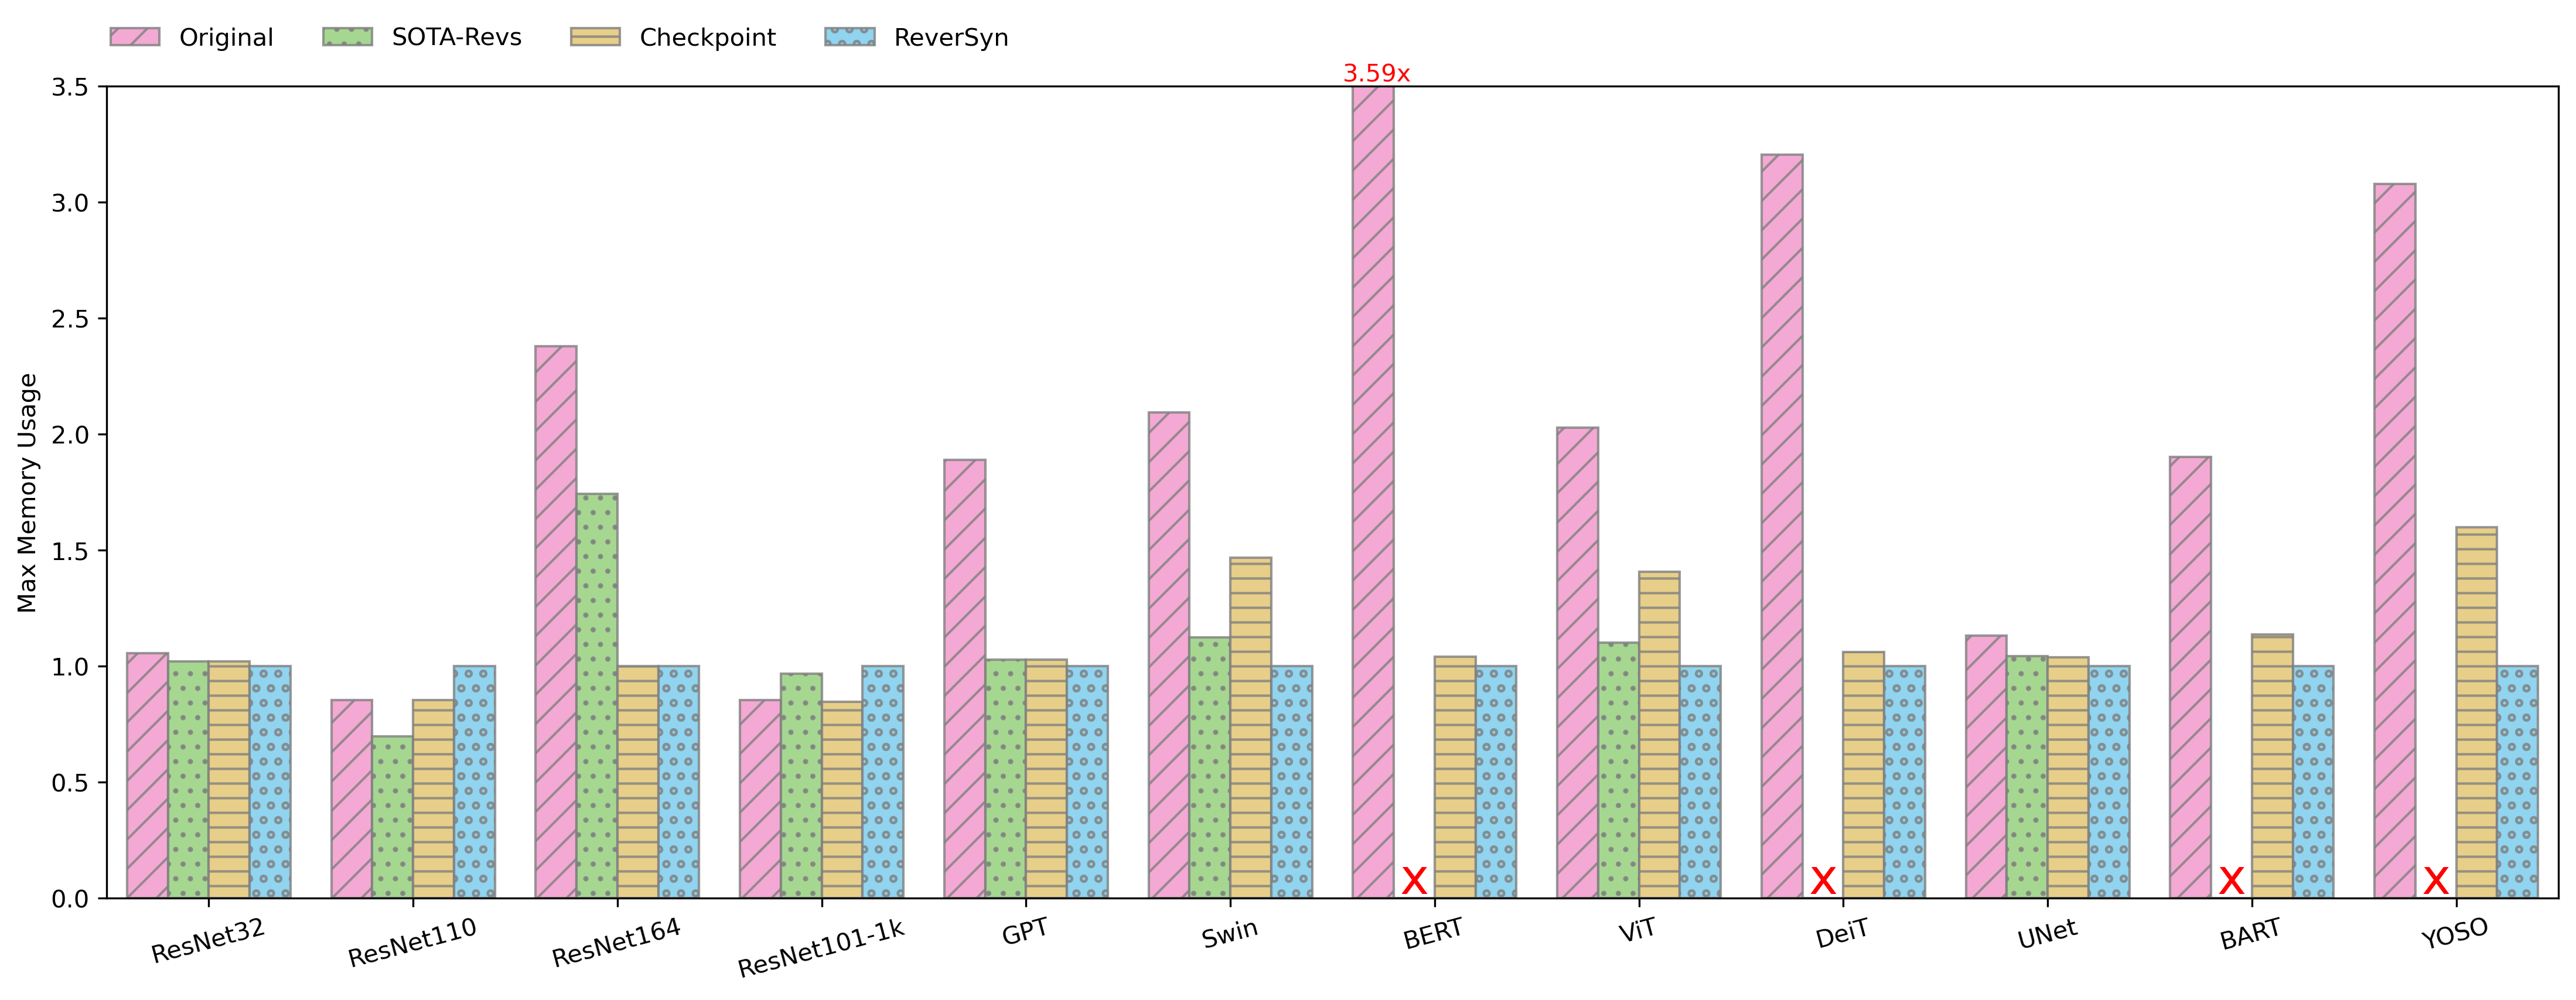

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 300

colors = ["#FF85CA", "#8ADD67", "#F6CC58", "#60D3FF"]
sns.set_palette(colors)

hatches = ["//", "..", "--", "oo"]

plt.rcParams["figure.figsize"] = (18, 6)
ax = sns.barplot(memory, x="model", y="ratio", hue="method", hue_order=["Original", "SOTA-Revs", "Checkpoint", "ReverSyn"], edgecolor="black", alpha=0.8)

plt.xlabel(None)
plt.ylabel("Max Memory Usage")
legend = plt.legend(loc="upper center", bbox_to_anchor=(0.185, 1.1), ncols=4, frameon=False)

for patch, hatch in zip(legend.get_patches(), hatches):
    patch.set_hatch(hatch)
    patch.set_edgecolor("gray")

plt.xticks(rotation=15)
plt.ylim(0, 3.5)

for i, bar in enumerate(ax.patches):
    bar.set_hatch(hatches[i // len(model_names)])
    bar.set_edgecolor("gray")
    
# bert base
bar = ax.patches[6]
plt.text(bar.get_x() - 0.05, 3.52, f'{memory[(memory.model == "BERT") & (memory.method == "Original")].ratio.item():.2f}x', color="red")

# manual
manual_indices = [18, 20, 22, 23]
for index in manual_indices:
    bar = ax.patches[index]
    plt.text(bar.get_x() + 0.03, 0.02, "x", color="red", fontsize=20)

## Latency

In [4]:
latency_normalized = []

for model in model_names:
    subtable = data[data.model == model]
    baseline = subtable[subtable.method == "ReverSyn"].latency.item()
    for method in method_names:
        row = subtable[subtable.method == method]
        row["ratio"] = row.latency.item() / baseline
        latency_normalized.append(row)
        
latency = pd.concat(latency_normalized)
latency

,model,method,latency,memory,cpu_time,gpu_time,acc,ratio
0,ResNet32,Original,0.014868,1552.0,35.949,18.640,0.0,0.987513
1,ResNet32,SOTA-Revs,0.027730,1500.0,76.855,34.582,0.0,1.841791
2,ResNet32,ReverSyn,0.015056,1470.0,35.930,18.674,0.0,1.000000
3,ResNet32,Checkpoint,0.034049,1500.0,99.575,41.028,0.0,2.261490
5,ResNet110,Original,0.047181,1850.0,111.048,62.956,0.0,0.267658
6,ResNet110,SOTA-Revs,0.089216,1510.0,251.122,98.516,0.0,0.506119
7,ResNet110,ReverSyn,0.176275,2164.0,500.258,147.204,0.0,1.000000
8,ResNet110,Checkpoint,0.063567,1850.0,186.473,79.992,0.0,0.360613
10,ResNet164,Original,0.299903,10862.0,0.000,0.000,0.0,0.181651
11,ResNet164,SOTA-Revs,1.442979,7958.0,0.000,0.000,0.0,0.874011


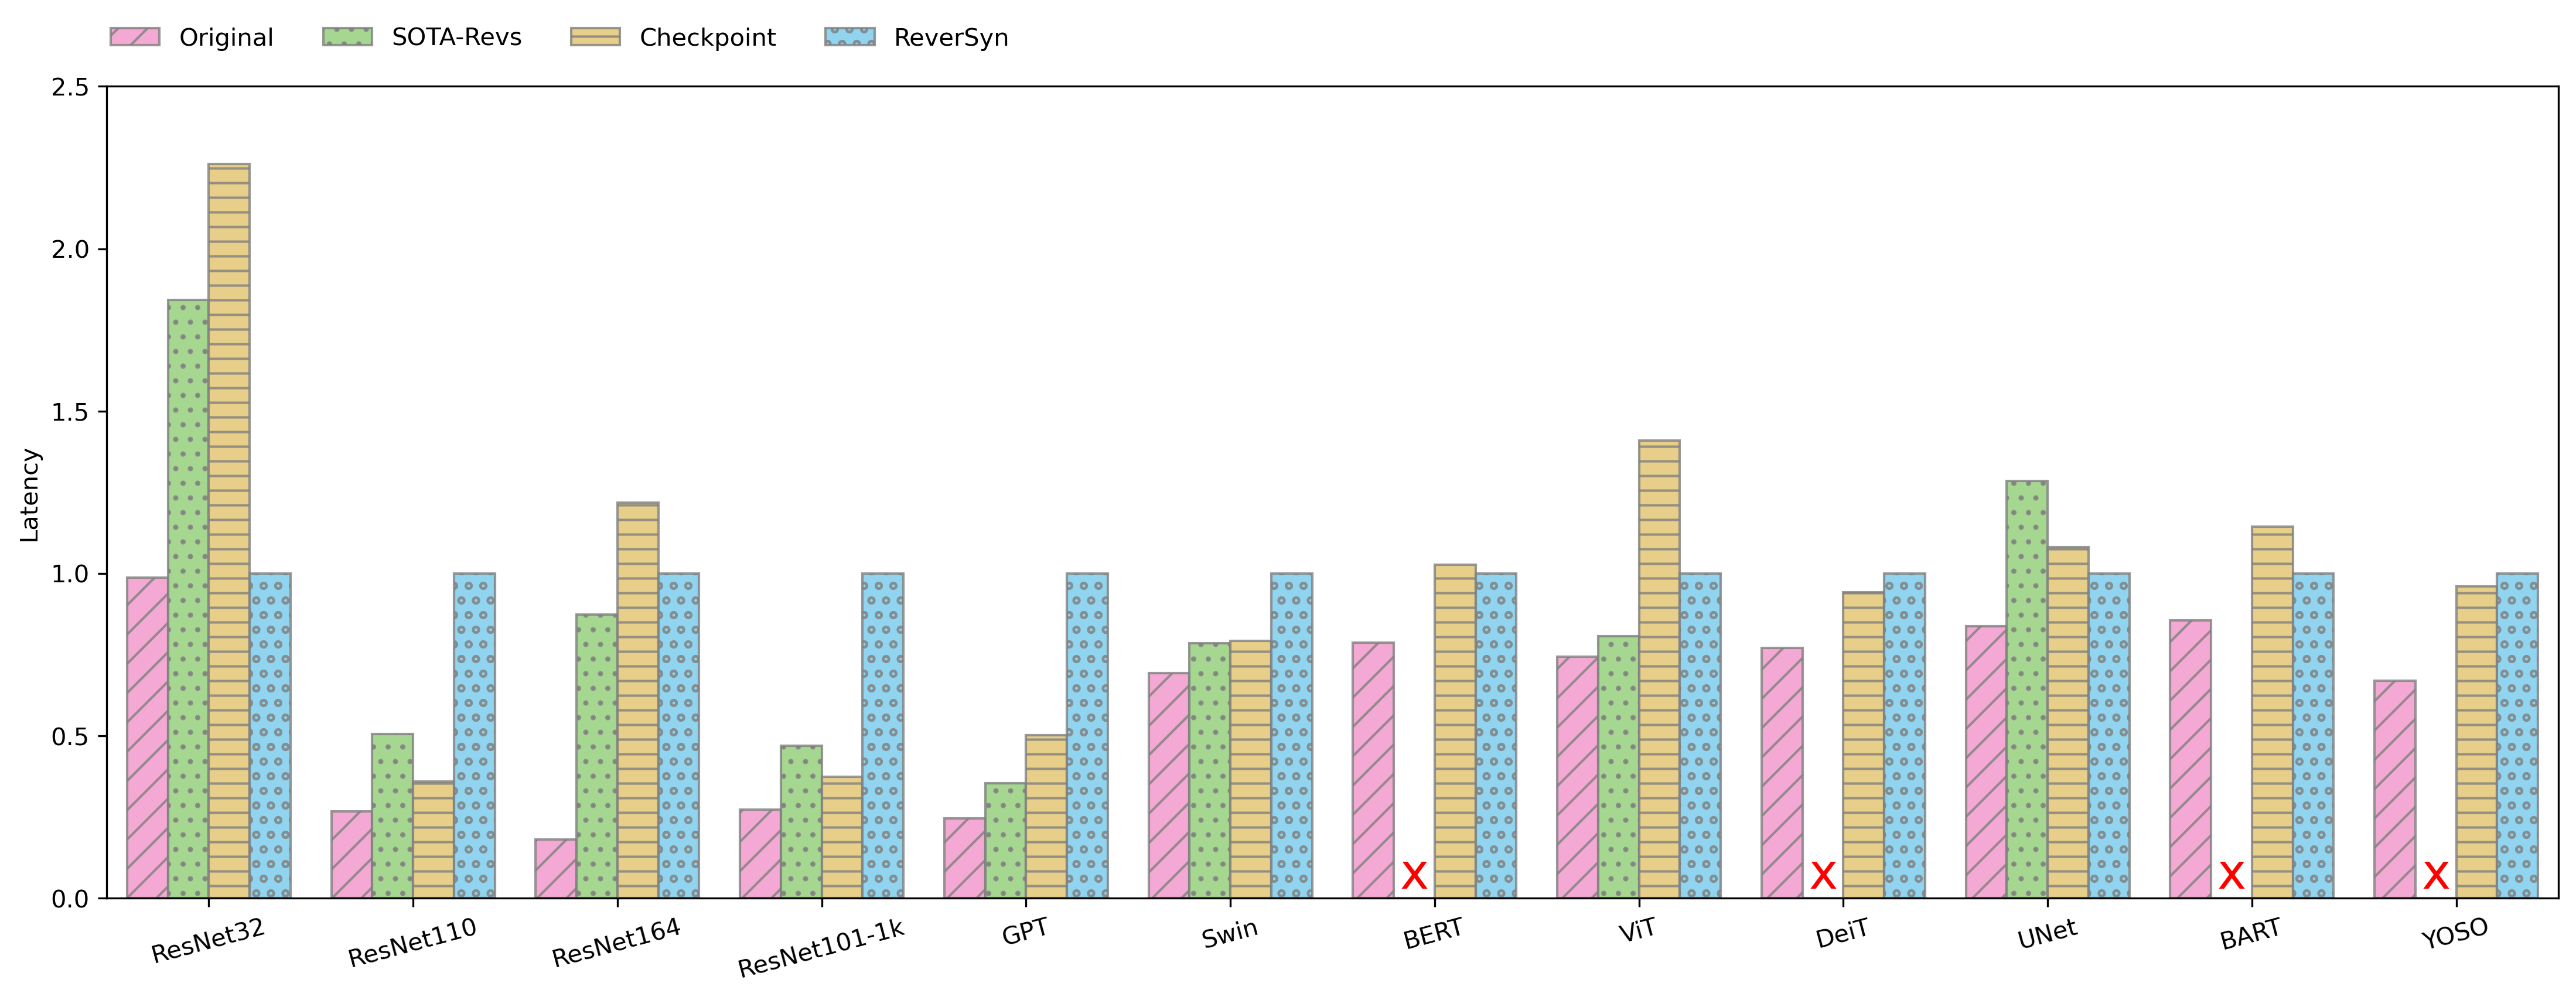

In [13]:
plt.rcParams["figure.figsize"] = (18, 6)
ax = sns.barplot(latency, x="model", y="ratio", hue="method", hue_order=["Original", "SOTA-Revs", "Checkpoint", "ReverSyn"], edgecolor="black", alpha=0.8)

plt.xlabel(None)
plt.ylabel("Latency")
legend = plt.legend(loc="upper center", bbox_to_anchor=(0.185, 1.1), ncols=4, frameon=False)

for patch, hatch in zip(legend.get_patches(), hatches):
    patch.set_hatch(hatch)
    patch.set_edgecolor("gray")

plt.xticks(rotation=15)
plt.ylim(0, 2.5)

for i, bar in enumerate(ax.patches):
    bar.set_hatch(hatches[i // len(model_names)])
    bar.set_edgecolor("gray")
    
# manual
manual_indices = [18, 20, 22, 23]
for index in manual_indices:
    bar = ax.patches[index]
    plt.text(bar.get_x() + 0.03, 0.03, "x", color="red", fontsize=20)

## Throughput

In [43]:
throughput_data = pd.read_csv("throughput.csv")
throughput_data = throughput_data.rename(columns={"Model": "model", "batch size": "batch_size"})
throughput_data = throughput_data.dropna(subset=["batch_size"])
throughput_data = throughput_data[["model", "method", "memory", "batch_size", "sequence", "latency", "throughput"]]

for old, new in zip(
    ["base", "manual", "reversify", "checkpoint"], 
    method_names
):
    throughput_data.loc[throughput_data.method == old, "method"] = new
    
for old, new in zip(
    ["resnet32", "resnet110", "resnet164", "resnet101-1k", "gpt", "swin", "bert", "vit", "deit", "unet", "bart", "yoso"],
    model_names
):
    throughput_data.loc[throughput_data.model == old, "model"] = new

# unet
unet = throughput_data[throughput_data.model == "UNet"]
throughput_data.loc[throughput_data.model == "UNet", "throughput"] = unet.batch_size / unet.latency

# yoso
yoso = throughput_data[throughput_data.model == "YOSO"]
throughput_data.loc[throughput_data.model == "YOSO", "throughput"] = yoso.batch_size / yoso.latency

throughput_data = throughput_data.dropna(subset=["throughput"])
throughput_data

,model,method,memory,batch_size,sequence,latency,throughput
15,ResNet101-1k,Original,11520.0,75.0,NaN,0.366320,208.333333
16,ResNet101-1k,SOTA-Revs,10758.0,20.0,NaN,0.649911,15.625000
17,ResNet101-1k,ReverSyn,11332.0,190.0,NaN,1.558625,122.580645
18,ResNet101-1k,Checkpoint,11516.0,75.0,NaN,0.472085,159.574468
20,GPT,Original,10862.0,40.0,100.0,0.299903,137.931035
21,GPT,SOTA-Revs,11138.0,80.0,100.0,1.223200,65.573770
22,GPT,ReverSyn,11466.0,100.0,100.0,0.747685,135.135135
23,GPT,Checkpoint,11332.0,70.0,100.0,0.773444,90.909091
30,BERT,Original,11326.0,14.0,512.0,0.359281,40.000000
32,BERT,ReverSyn,11436.0,100.0,512.0,2.840509,35.211268


In [54]:
throughput_normalized = []

for model in model_names:
    subtable = throughput_data[data.model == model]
    if subtable.empty:
        continue
    baseline = subtable[subtable.method == "ReverSyn"].throughput.item()
    for method in method_names:
        row = subtable[subtable.method == method]
        if row.empty:
            continue
        row["ratio"] = row.throughput.item() / baseline
        throughput_normalized.append(row)
        
throughput_normalized = pd.concat(throughput_normalized)
throughput_normalized

,model,method,memory,batch_size,sequence,latency,throughput,ratio
15,ResNet101-1k,Original,11520.0,75.0,NaN,0.366320,208.333333,1.699561
16,ResNet101-1k,SOTA-Revs,10758.0,20.0,NaN,0.649911,15.625000,0.127467
17,ResNet101-1k,ReverSyn,11332.0,190.0,NaN,1.558625,122.580645,1.000000
18,ResNet101-1k,Checkpoint,11516.0,75.0,NaN,0.472085,159.574468,1.301792
20,GPT,Original,10862.0,40.0,100.0,0.299903,137.931035,1.020690
21,GPT,SOTA-Revs,11138.0,80.0,100.0,1.223200,65.573770,0.485246
22,GPT,ReverSyn,11466.0,100.0,100.0,0.747685,135.135135,1.000000
23,GPT,Checkpoint,11332.0,70.0,100.0,0.773444,90.909091,0.672727
30,BERT,Original,11326.0,14.0,512.0,0.359281,40.000000,1.136000
32,BERT,ReverSyn,11436.0,100.0,512.0,2.840509,35.211268,1.000000


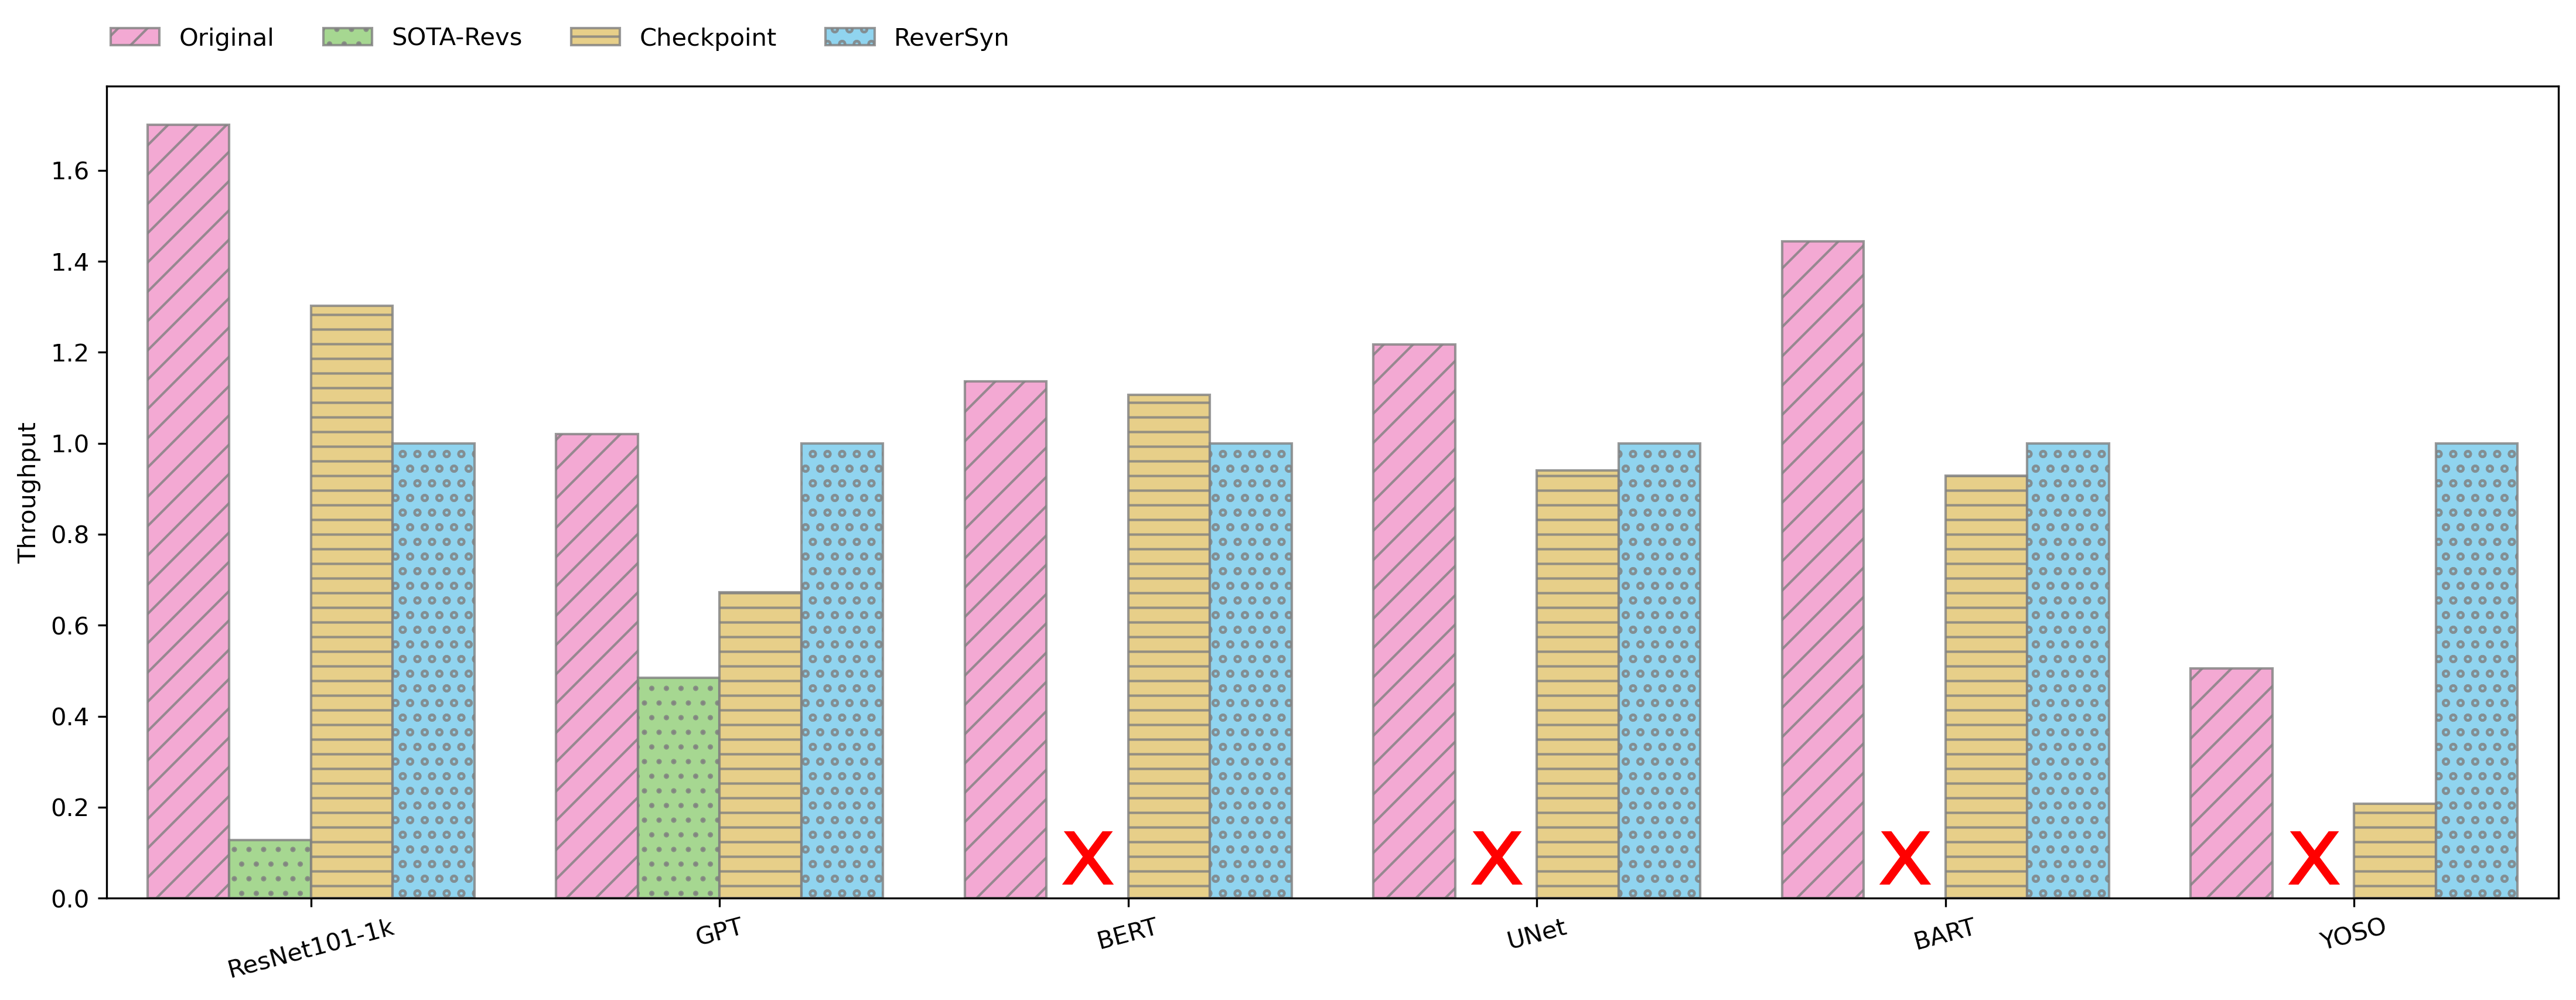

In [72]:
plt.rcParams["figure.figsize"] = (18, 6)
ax = sns.barplot(throughput_normalized, x="model", y="ratio", hue="method", hue_order=["Original", "SOTA-Revs", "Checkpoint", "ReverSyn"], edgecolor="black", alpha=0.8)

plt.xlabel(None)
plt.ylabel("Throughput")
legend = plt.legend(loc="upper center", bbox_to_anchor=(0.185, 1.1), ncols=4, frameon=False)

for patch, hatch in zip(legend.get_patches(), hatches):
    patch.set_hatch(hatch)
    patch.set_edgecolor("gray")

plt.xticks(rotation=15)

for i, bar in enumerate(ax.patches):
    bar.set_hatch(hatches[i // len(set(throughput_data.model))])
    bar.set_edgecolor("gray")
    
# manual
manual_indices = [8, 9, 10, 11]
for index in manual_indices:
    bar = ax.patches[index]
    plt.text(bar.get_x() + 0.03, 0.03, "x", color="red", fontsize=40)

## Optimization

In [128]:
optimization_data = pd.read_csv("optimization.csv")

def process_optimization_data(model):
    subtable = optimization_data[optimization_data.model == model]
    time = []
    memory = []
    method = []
    
    for col in subtable.drop(["model", "info"], axis=1):
        if "Unnamed" in col:
            memory.append(subtable[col].item())
        else:
            time.append(subtable[col].item())
            method.append(col)
            
    return pd.DataFrame({"model": [model] * len(method), "method": method, "time": time, "memory": memory})

optimization_data = pd.concat([process_optimization_data(model) for model in set(optimization_data.model)])
optimization_data = optimization_data[optimization_data.method.str.contains("rev")]
rename_models(optimization_data)

optimization_data

,model,method,time,memory
2,ResNet164,rev,0.374182,2390
4,ResNet164,rev+cp,0.428476,2468
5,ResNet164,rev+off loading,1.227964,2230
6,ResNet164,rev+amp,0.436292,2262
7,ResNet164,rev+amp+cp,0.431811,2262
8,ResNet164,rev+amp+ol,0.374822,2394
9,ResNet164,rev+cp+ol,1.248220,2230
10,ResNet164,rev+amp+cp+ol,0.433921,2262
2,GPT,rev,0.622287,6798
4,GPT,rev+cp,0.430292,5848


In [157]:
opt = optimization_data.copy()

for model in ["ResNet164", "GPT"]:
    time_baseline = opt[(opt.model == model) & (opt.method == "rev")].time.item()
    memory_baseline = opt[(opt.model == model) & (opt.method == "rev")].memory.item()
    for method in list(set(opt.method)):
        method_time = opt[(opt.model == model) & (opt.method == method)].time.item()
        method_memory = opt[(opt.model == model) & (opt.method == method)].memory.item()
        opt.loc[(opt.model == model) & (opt.method == method), "time_ratio"] = 1 - method_time / time_baseline
        opt.loc[(opt.model == model) & (opt.method == method), "memory_ratio"] = 1 - method_memory / memory_baseline

opt

,model,method,time,memory,time_ratio,memory_ratio
2,ResNet164,rev,0.374182,2390,0.000000,0.000000
4,ResNet164,rev+cp,0.428476,2468,-0.145100,-0.032636
5,ResNet164,rev+off loading,1.227964,2230,-2.281728,0.066946
6,ResNet164,rev+amp,0.436292,2262,-0.165989,0.053556
7,ResNet164,rev+amp+cp,0.431811,2262,-0.154014,0.053556
8,ResNet164,rev+amp+ol,0.374822,2394,-0.001711,-0.001674
9,ResNet164,rev+cp+ol,1.248220,2230,-2.335862,0.066946
10,ResNet164,rev+amp+cp+ol,0.433921,2262,-0.159653,0.053556
2,GPT,rev,0.622287,6798,0.000000,0.000000
4,GPT,rev+cp,0.430292,5848,0.308531,0.139747


(array([0, 1]), [Text(0, 0, 'ResNet164'), Text(1, 0, 'GPT')])

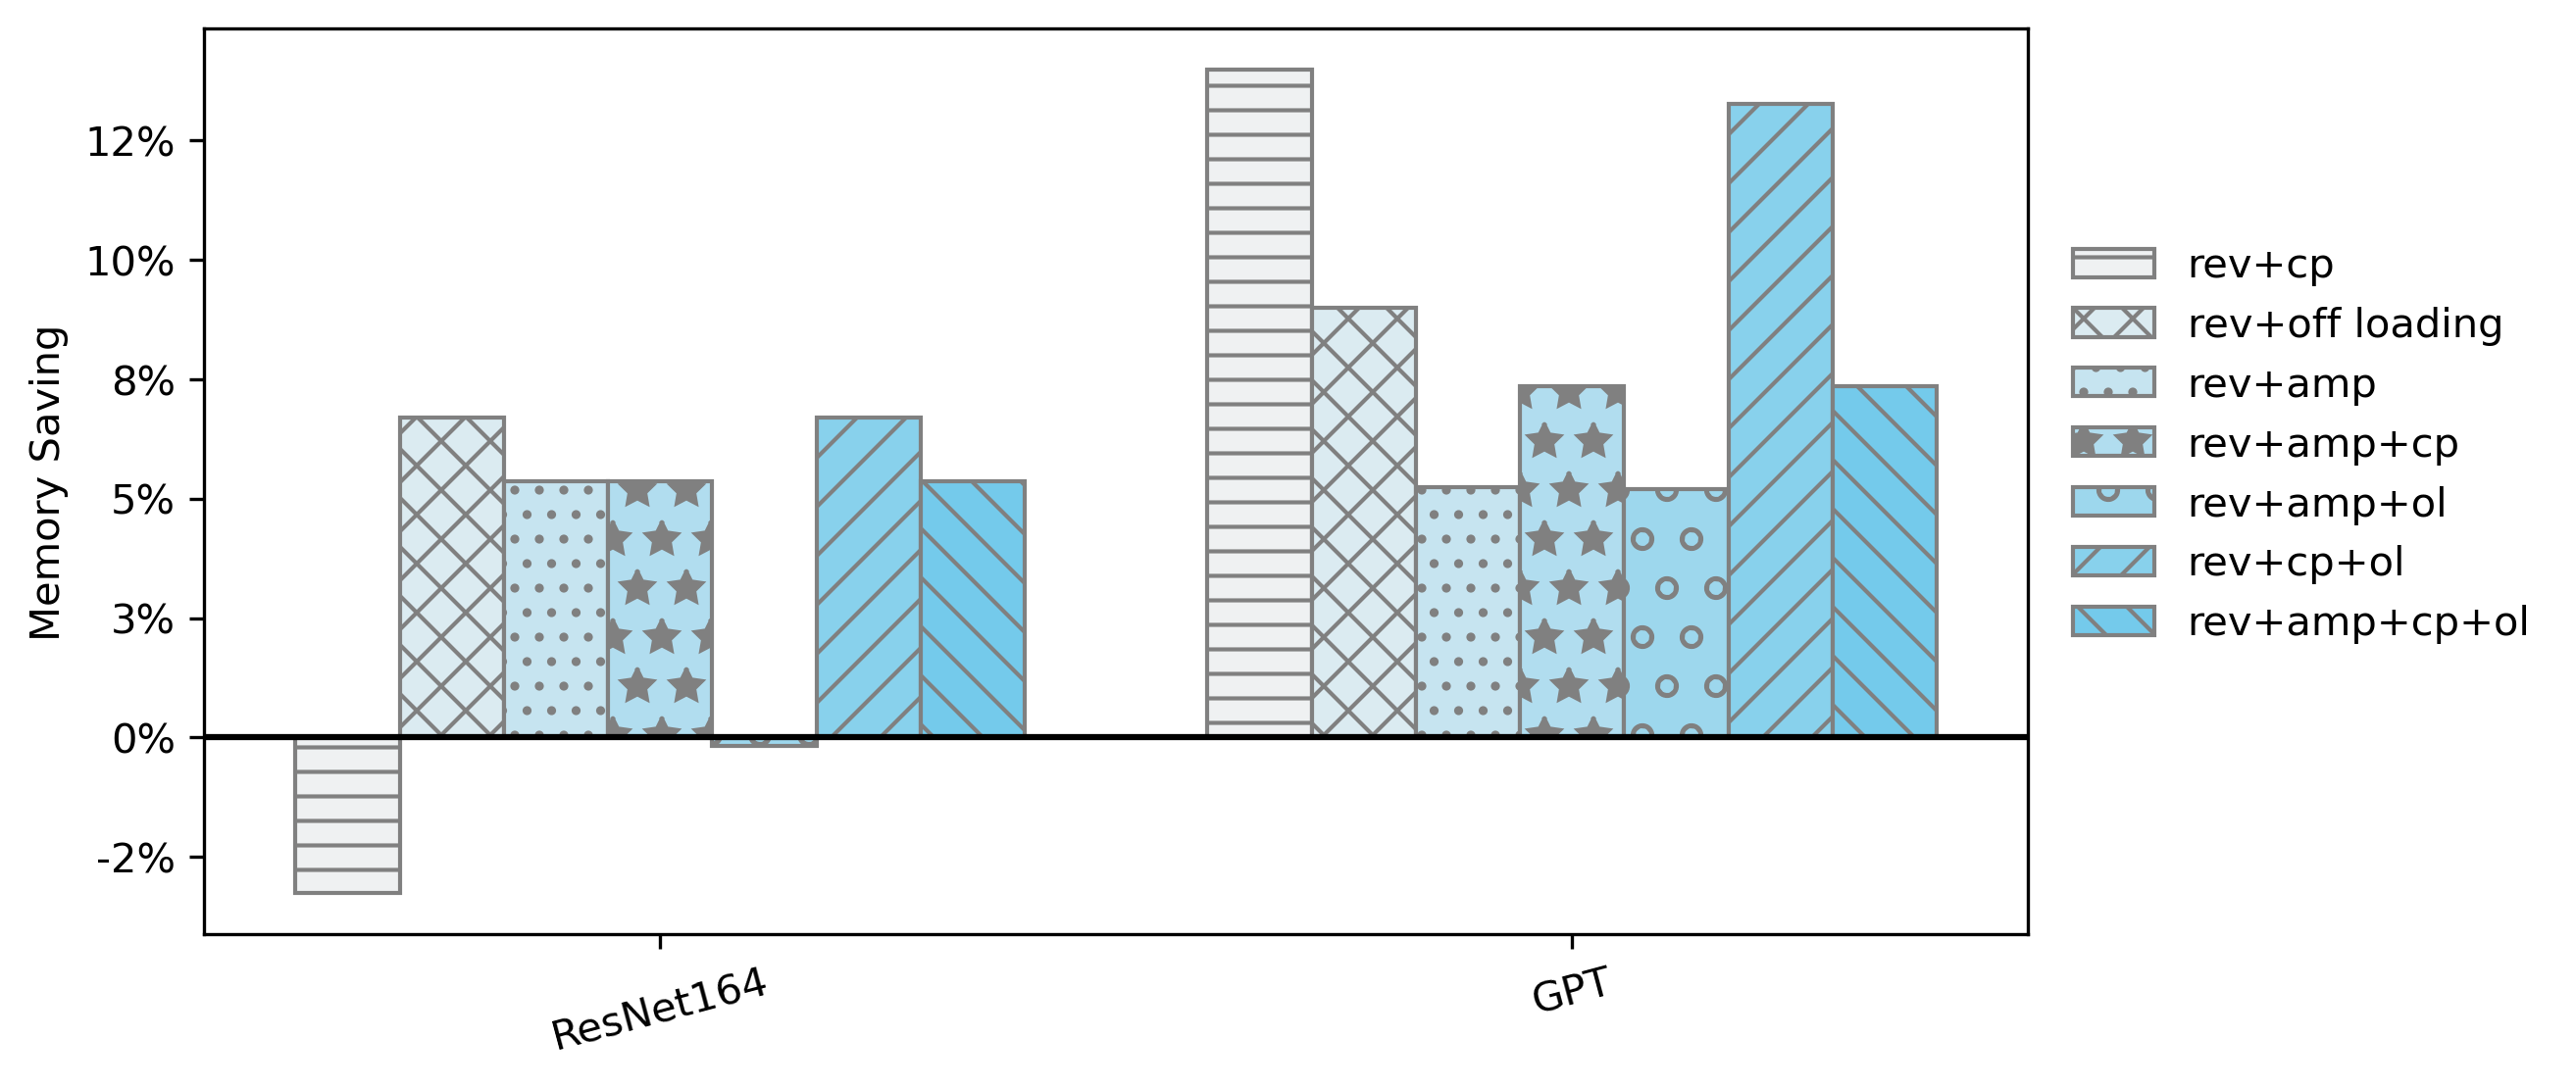

In [229]:
from matplotlib.ticker import FuncFormatter

hatches_7 = ["--", "xx", "..", "*", "o", "//", "\\\\"]

plt.rcParams["figure.figsize"] = (8, 4)
ax = sns.barplot(opt[opt.method != "rev"], x="model", y="memory_ratio", hue="method", color=colors[-1])
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.axhline(y=0, color="black", linestyle="-")

plt.xlabel(None)
plt.ylabel("Memory Saving")
legend = plt.legend(loc="upper center", bbox_to_anchor=(1.15, 0.8), ncols=1, frameon=False)

for patch, hatch in zip(legend.get_patches(), hatches_7):
    patch.set_hatch(hatch)
    patch.set_edgecolor("gray")

for i, bar in enumerate(ax.patches):
    bar.set_hatch(hatches_7[i // 2])
    bar.set_edgecolor("gray")

plt.xticks(rotation=15)

## Breakdown

In [230]:
breakdown_data = pd.read_csv("breakdown.csv")

breakdown_data

,model,base,Unnamed: 2,manual,Unnamed: 4,rev,Unnamed: 6,compile time,rev+dp,Unnamed: 9,compile time.1,info
0,resnet,0.156139,7854,0.331934,3070,NaN,NaN,NaN,0.122914,3150.0,55.766586,"{'layer1.10': 'additive', 'layer1.11': 'additi..."
1,gpt,0.299903,10862,1.004120,6914,NaN,NaN,NaN,NaN,NaN,NaN,NaN
